In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
!apt-get -y install ffmpeg libreoffice poppler-utils poppler-data locales \
                   fonts-noto-cjk fonts-noto-cjk-extra fonts-nanum fonts-unfonts-core
!sed -i 's/^# *ko_KR.UTF-8 UTF-8/ko_KR.UTF-8 UTF-8/' /etc/locale.gen
!locale-gen ko_KR.UTF-8
!update-locale LANG=ko_KR.UTF-8
!fc-cache -fv

%%bash
mkdir -p ~/.config/fontconfig
cat > ~/.config/fontconfig/fonts.conf <<'EOF'
<?xml version="1.0"?>
<!DOCTYPE fontconfig SYSTEM "fonts.dtd">
<fontconfig>

  <!-- ▷ 한국어 텍스트엔 Noto Sans CJK KR을 우선 사용 -->
  <match target="pattern">
    <test name="lang" compare="eq"><string>ko</string></test>
    <edit name="family" mode="prepend" binding="strong">
      <string>Noto Sans CJK KR</string>
    </edit>
  </match>

  <!-- ▷ 일반 가족명에도 기본 대체 추가 -->
  <alias><family>sans-serif</family><prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>serif</family><prefer><family>Noto Serif CJK KR</family></prefer></alias>
  <alias><family>monospace</family><prefer><family>Noto Sans Mono CJK KR</family></prefer></alias>

  <!-- ▷ Windows/macOS/웹에서 흔한 한글 폰트들을 Noto로 매핑 -->
  <alias><family>Malgun Gothic</family>        <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>맑은 고딕</family>             <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>Apple SD Gothic Neo</family>  <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>AppleGothic</family>          <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>Pretendard</family>           <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>Pretendard Variable</family>  <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>NanumSquare</family>          <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>Spoqa Han Sans</family>       <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>KoPub</family>                <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>Gulim</family>                <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>Dotum</family>                <prefer><family>Noto Sans CJK KR</family></prefer></alias>
  <alias><family>Batang</family>               <prefer><family>Noto Serif CJK KR</family></prefer></alias>
</fontconfig>
EOF
fc-cache -fv

SyntaxError: invalid character '▷' (U+25B7) (ipython-input-1751882520.py, line 14)

Data shape: (475425, 128)
Period: 2024-12-01 16:41:00 ~ 2025-10-31 23:59:00

=== Features with smallest variance (Top 20) ===
volatility_fd0.4    2.699171e-08
volatility          3.219380e-07
log_return          5.409662e-07
volatility_15m      2.324790e-06
volatility_30m      4.249953e-06
log_return_15m      5.669378e-06
volatility_1h       8.083908e-06
log_return_30m      1.092767e-05
bb_width            1.500459e-05
volatility_4h       1.517450e-05
volatility_6h       1.999969e-05
log_return_1h       2.156496e-05
log_return_4h       6.279555e-05
log_return_6h       9.042453e-05
bb_width_15m        1.068375e-04
bb_width_30m        1.957406e-04
bb_width_1h         3.530036e-04
bb_width_4h         9.118396e-04
bb_width_6h         1.248336e-03
bb_pct_fd0.4        3.857138e-02
dtype: float64

=== Features with largest variance (Top 20) ===
sma_20_15m    1.955391e+14
ema_12_15m    1.955813e+14
sma_5_1h      1.956068e+14
sma_10_30m    1.956117e+14
high          1.956606e+14
sma_10_15m    1

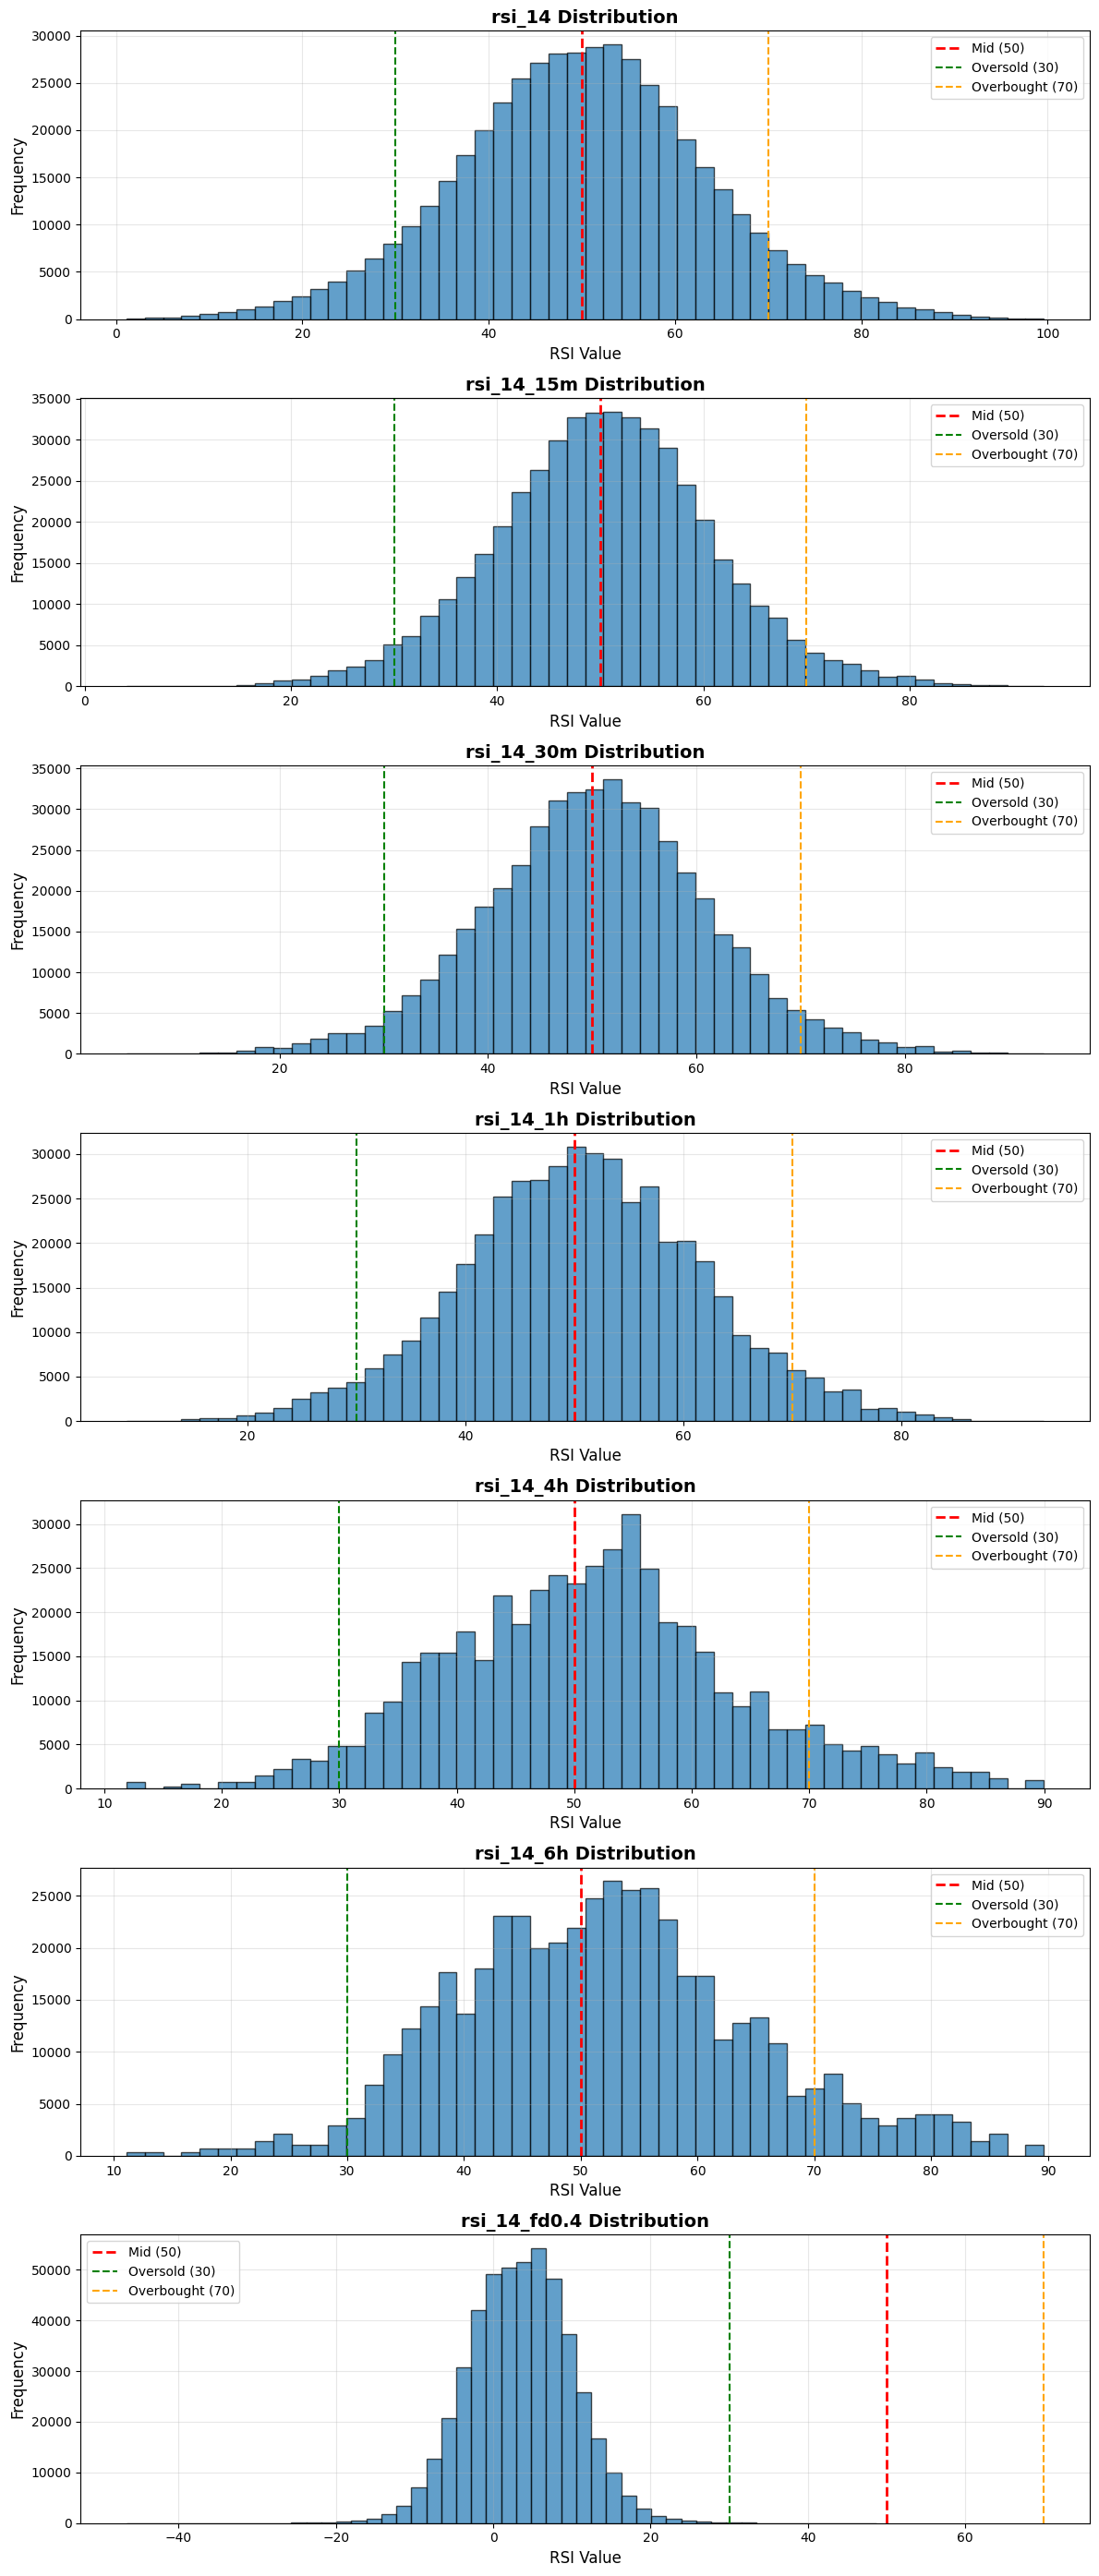


✅ Cleaned data saved: df_1m_cleaned.csv

Analysis complete!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/btc_trading_bot/df_cleaned.csv', index_col=0, parse_dates=True)

print(f"Data shape: {df.shape}")
print(f"Period: {df.index.min()} ~ {df.index.max()}\n")

# 1. Variance
variances = df.var()
variances_sorted = variances.sort_values()
print("=== Features with smallest variance (Top 20) ===")
print(variances_sorted.head(20))
print("\n=== Features with largest variance (Top 20) ===")
print(variances_sorted.tail(20))

# 2. Features with variance exactly 0
zero_variance_features = variances[variances == 0.0]
if len(zero_variance_features) > 0:
    print(f"\n⚠️ Zero-variance features ({len(zero_variance_features)}):")
    for col in zero_variance_features.index:
        print(f"  - {col}: variance={zero_variance_features[col]:.10f}")
        print(f"    ⇒ unique values: {df[col].nunique()}, sample: {df[col].head(5).tolist()}")
else:
    print("\n✅ No zero-variance features!")

# 3. Perfectly correlated features
print("\n=== Perfectly correlated feature pairs (correlation ≈ 1) ===")
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
perfect_corr_pairs = []
for col in upper_tri.columns:
    for row in upper_tri.index:
        corr_val = upper_tri.loc[row, col]
        if pd.notna(corr_val) and corr_val >= 0.9999:
            perfect_corr_pairs.append((col, row, corr_val))
if perfect_corr_pairs:
    print(f"⚠️ {len(perfect_corr_pairs)} perfect-correlation pairs:")
    for col1, col2, corr in sorted(perfect_corr_pairs, key=lambda x: x[2], reverse=True):
        print(f"  - {col1} ↔ {col2}: {corr:.6f}")
else:
    print("✅ No perfectly correlated feature pairs!")

# 4. Features for removal
features_to_drop = []
features_to_drop.extend(zero_variance_features.index.tolist())
dropped_from_corr = set()
for col1, col2, corr in perfect_corr_pairs:
    if col1 not in dropped_from_corr and col2 not in dropped_from_corr:
        features_to_drop.append(col2)
        dropped_from_corr.add(col2)
        print(f"  → {col2} will be dropped (duplicate of {col1})")
features_to_drop = list(set(features_to_drop))

print("\n" + "="*60)
print(f"Features to drop: {len(features_to_drop)}")
for feat in features_to_drop:
    reason = "zero variance" if feat in zero_variance_features.index else "correlation=1"
    print(f"  - {feat} ({reason})")
if not features_to_drop:
    print("✅ All features are valid. No removal needed.")
print("="*60)

# 5. RSI summary
rsi_cols = [col for col in df.columns if 'rsi' in col.lower()]
if rsi_cols:
    print("\n" + "="*60)
    print(f"RSI feature summaries ({len(rsi_cols)} total):")
    print("="*60)
    for col in rsi_cols:
        print(f"\n{col}:")
        print(f"  Mean: {df[col].mean():.4f}")
        print(f"  Std: {df[col].std():.4f}")
        print(f"  Min: {df[col].min():.4f}")
        print(f"  Max: {df[col].max():.4f}")
        print(f"  Median: {df[col].median():.4f}")
        near_50 = ((df[col] > 49) & (df[col] < 51)).mean() * 100
        print(f"  Share in 49~51: {near_50:.2f}%")
    # RSI distribution
    fig, axes = plt.subplots(len(rsi_cols), 1, figsize=(12, 4*len(rsi_cols)))
    if len(rsi_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, rsi_cols):
        df[col].hist(bins=50, ax=ax, edgecolor='black', alpha=0.7)
        ax.set_title(f'{col} Distribution', fontsize=14, fontweight='bold')
        ax.set_xlabel('RSI Value', fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
        ax.axvline(50, color='red', linestyle='--', linewidth=2, label='Mid (50)')
        ax.axvline(30, color='green', linestyle='--', linewidth=1.5, label='Oversold (30)')
        ax.axvline(70, color='orange', linestyle='--', linewidth=1.5, label='Overbought (70)')
        ax.legend(fontsize=10)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/btc_trading_bot/rsi_distribution.png', dpi=150, bbox_inches='tight')
    print("\nRSI distribution plot saved: rsi_distribution.png")
    plt.show()

# 6. Save cleaned DataFrame (if any features to drop)
if features_to_drop:
    df_cleaned = df.drop(columns=features_to_drop)
    df_cleaned.to_csv('/content/drive/MyDrive/btc_trading_bot/df_1m_cleaned.csv')
    print(f"\n✅ Cleaned data saved: df_1m_cleaned.csv")
else:
    print("\nNo cleaning needed.")

print("\nAnalysis complete!")


In [4]:
print(df_cleaned.head(10))

                       volume         value     rsi_14          macd  \
datetime                                                               
2024-12-01 16:41:00  0.843146  1.130286e+08  25.493033 -17323.789448   
2024-12-01 16:42:00  1.959468  2.626973e+08  24.054123 -21215.990449   
2024-12-01 16:43:00  2.087224  2.798212e+08  45.164325 -19476.649461   
2024-12-01 16:44:00  0.599091  8.035225e+07  55.073732 -14541.534448   
2024-12-01 16:45:00  0.633044  8.489678e+07  45.053276 -14338.335684   
2024-12-01 16:46:00  1.168494  1.566853e+08  44.688429 -14175.278695   
2024-12-01 16:47:00  0.882766  1.183788e+08  43.000867 -14603.934574   
2024-12-01 16:48:00  0.367801  4.933114e+07  45.932593 -13816.084512   
2024-12-01 16:49:00  1.277532  1.713607e+08  57.505518  -8334.822105   
2024-12-01 16:50:00  0.874537  1.173342e+08  59.408592  -2988.137061   

                         macd_sig     macd_hist       bb_mid  bb_width  \
datetime                                                     